# **MACHINE LEARNING**
## **Gradient Boosting — Prediciendo la Diabetes**

In [190]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import joblib
import os

In [191]:
# Carga del dataset

csv_file_path = "/content/sample_data/diabetes.csv"
df = pd.read_csv(csv_file_path)

print(df.shape)
df.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


Este dataset tiene **768 filas y 9 columnas**, todas las variables son numéricas.

In [192]:
# 2.1 INFORMACIÓN GENERAL DEL DATASET

print(" INFORMACIÓN GENERAL DEL DATASET")
df.info()

 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Vemos que el dataset **no tiene ningún valor nulo** y que todas las columnas tienen valores de tipo numérico, tanto `int` como `float`.

In [193]:
# 2.2 ESTADÍSTICAS DESCRIPTIVAS

df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


`.describe()` muestra estadísticas de todas las columnas. Hay varias con mínimos de cero, lo que es imposible fisiológicamente — indica **valores faltantes enmascarados como cero**.

In [194]:
# 2.3 VALORES NULOS

print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\n Total valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

 Total valores nulos: 0


No hay valores nulos explícitos, pero los ceros en columnas médicas actúan como valores faltantes encubiertos.

In [195]:
# 2.4 VALORES CERO (POTENCIALMENTE VALORES FALTANTES)

cols_con_ceros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Valores cero en columnas médicas (probables valores faltantes):")
for col in cols_con_ceros:
    ceros = (df[col] == 0).sum()
    pct = ceros / len(df) * 100
    print(f"   {col:30s} → {ceros:3d} ceros ({pct:.1f}%)")

Valores cero en columnas médicas (probables valores faltantes):
   Glucose                        →   5 ceros (0.7%)
   BloodPressure                  →  35 ceros (4.6%)
   SkinThickness                  → 227 ceros (29.6%)
   Insulin                        → 374 ceros (48.7%)
   BMI                            →  11 ceros (1.4%)


Columnas como `SkinThickness` (29.6%) e `Insulin` (48.7%) tienen una proporción elevada de ceros, biológicamente imposibles.

In [196]:
# 2.5 TRATAMIENTO DE VALORES CERO → IMPUTACIÓN POR MEDIANA

df_clean = df.copy()

for col in cols_con_ceros:
    mediana = df_clean[col].replace(0, np.nan).median()
    df_clean[col] = df_clean[col].replace(0, mediana)
    print(f" {col}: 0s → mediana = {mediana:.2f}")

print("\nImputación completada")

 Glucose: 0s → mediana = 117.00
 BloodPressure: 0s → mediana = 72.00
 SkinThickness: 0s → mediana = 29.00
 Insulin: 0s → mediana = 125.00
 BMI: 0s → mediana = 32.30

Imputación completada


Se usa la **mediana** porque es robusta frente a outliers (especialmente importante en `Insulin`, que tiene valores muy extremos).

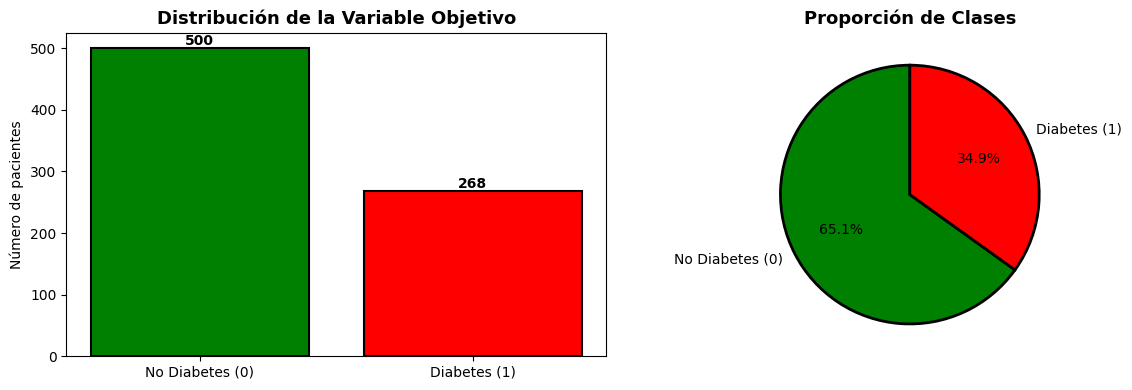


 Distribución:
   No Diabetes (0): 500 pacientes (65.1%)
   Diabetes    (1): 268 pacientes (34.9%)

 Hay cierto desbalance de clases (más negativos que positivos)


In [197]:
# 2.6 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
counts = df_clean['Outcome'].value_counts()
axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
            counts.values,
            color=['green', 'red'],
            edgecolor='black',
            linewidth=1.5)
axes[0].set_title('Distribución de la Variable Objetivo', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Número de pacientes')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(counts.values,
            labels=['No Diabetes (0)', 'Diabetes (1)'],
            autopct='%1.1f%%',
            colors=['green', 'red'],
            startangle=90,
            wedgeprops={'edgecolor': 'black', 'linewidth': 2})
axes[1].set_title('Proporción de Clases', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Distribución:")
print(f"   No Diabetes (0): {counts[0]} pacientes ({counts[0]/len(df_clean)*100:.1f}%)")
print(f"   Diabetes    (1): {counts[1]} pacientes ({counts[1]/len(df_clean)*100:.1f}%)")
print("\n Hay cierto desbalance de clases (más negativos que positivos)")

Podemos observar un desbalance de clases, hay un **65% de No Diabetes** vs un **35% de Diabetes.** Es importnate mantener esta proporción en el modelo.

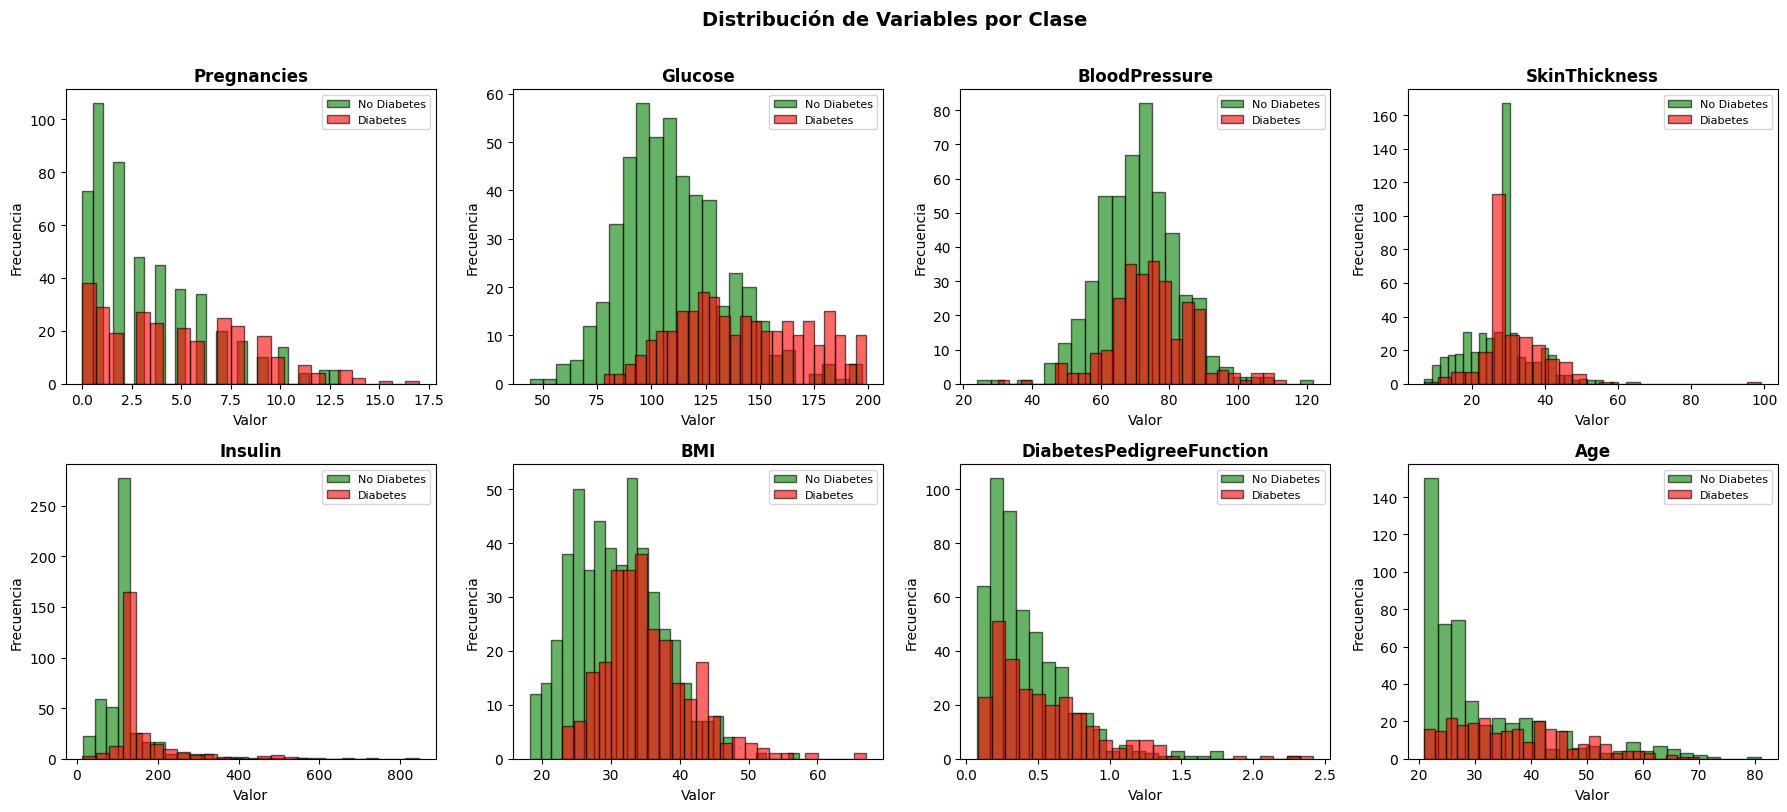

In [198]:
# 2.7 DISTRIBUCIÓN DE CADA VARIABLE

features = [c for c in df_clean.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df_clean[df_clean['Outcome'] == 0][col],
                 bins=25,
                 alpha=0.6,
                 color='green',
                 label='No Diabetes',
                 edgecolor='black')
    axes[i].hist(df_clean[df_clean['Outcome'] == 1][col],
                 bins=25,
                 alpha=0.6,
                 color='red',
                 label='Diabetes',
                 edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

plt.suptitle('Distribución de Variables por Clase', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos histogramas superpuestos nos revelan que variables diferencian mejor diabeticos de no diabeticos:
- **Glucose**: obviamente la glucosa es el valor que más diferencia a dibeticos de no dibeticos.
- **BMI** y **Age**: También nos muestra claras diferencias.
- **SkinThickness** e **Insulin**: Muestran diferencias más leves.

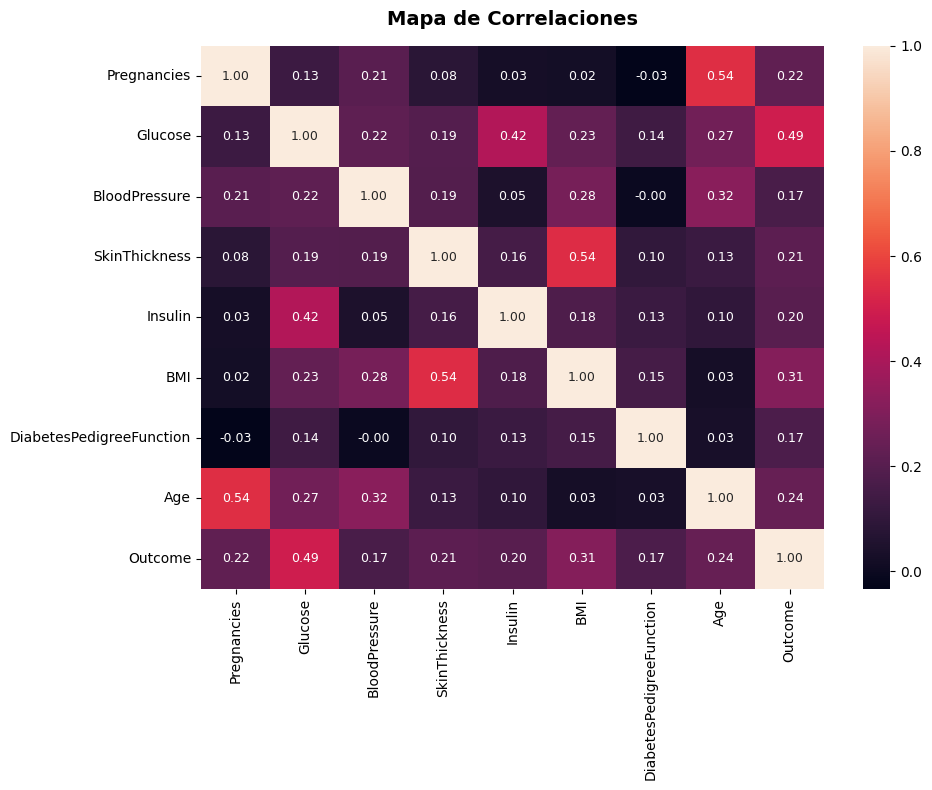

In [199]:
# 2.8 MAPA DE CORRELACIONES

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df_clean.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            ax=ax,
            annot_kws={'size': 9})
ax.set_title('Mapa de Correlaciones', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Este heatmap nos confirma que la variable más correlacionada con `Outcome` es `Glucose` con casi un 0.50. Seguidas de `BMI`, `Age` y `Pregnancies`.

Las correlaciones en general son bajas, esto beneficia al decission tree.

/tmp/ipykernel_5523/4034779494.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_5523/4034779494.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_5523/4034779494.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp/ipykernel_5523/4034779494.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_si],
/tmp

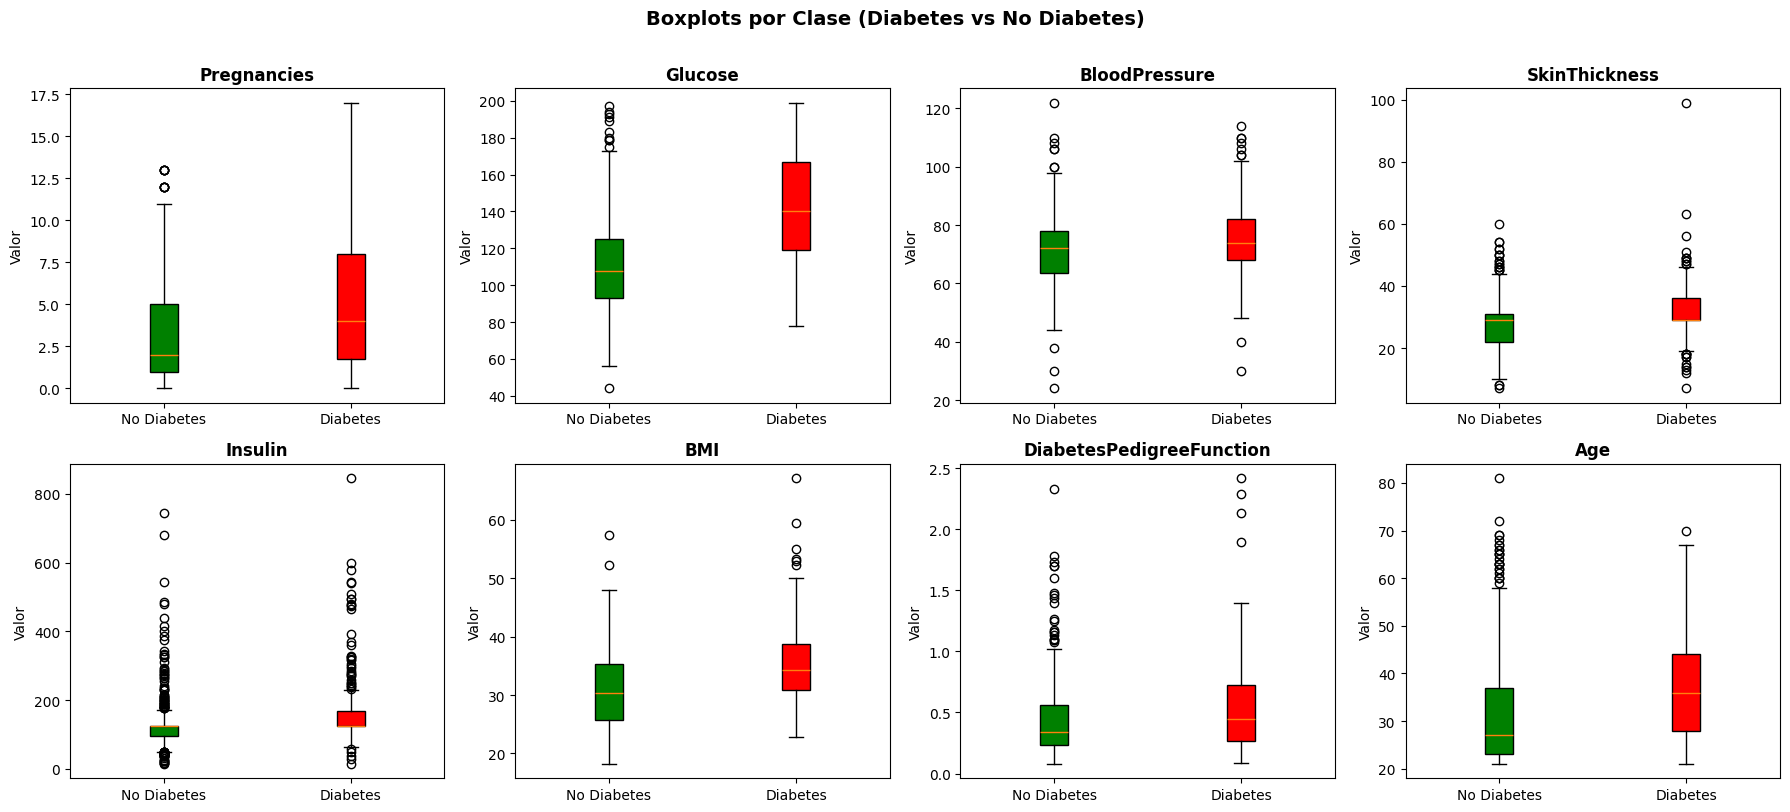

In [200]:
# 2.9 BOXPLOTS POR CLASE

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    data_no = df_clean[df_clean['Outcome'] == 0][col]
    data_si = df_clean[df_clean['Outcome'] == 1][col]
    bp = axes[i].boxplot([data_no, data_si],
                          patch_artist=True,
                          labels=['No Diabetes', 'Diabetes'])
    bp['boxes'][0].set_facecolor('green')
    bp['boxes'][1].set_facecolor('red')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Valor')

plt.suptitle('Boxplots por Clase (Diabetes vs No Diabetes)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Estos boxplots muestran **medianas, cuartiles y outliers** de cada variable, vamos a ver algunos.
- **Glucose**: la median de diabeticos esta por encima de la de no diabetcos.
- **Insulin** y **SkinThickness**: podemos apreciar muchos outliers.
- Aunque hay diferencias, vemos que no hay demasiada en **BloodPreasure**.

In [201]:
# 2.10 PAIRPLOT DE VARIABLES MÁS RELEVANTES

corr_target = df_clean.corr()['Outcome'].drop('Outcome').abs().sort_values(ascending=False)
top_features = corr_target.head(5).index.tolist() + ['Outcome']
print(f"Top 5 variables más correlacionadas con Outcome: {top_features[:-1]}")

sns.pairplot(df_clean[top_features],
             hue='Outcome',
             palette={0: 'green', 1: 'red'},
             height=2.2,
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot - Top 5 Variables vs Outcome', y=1.01, fontsize=13, fontweight='bold')
plt.show()

Top 5 variables más correlacionadas con Outcome: ['Glucose', 'BMI', 'Age', 'Pregnancies', 'SkinThickness']


El pairplot es un gráfico que cruza cada variable con `Outcome`, podemos apreciar que el par `Glucose + BMI` muestra la mayor separación visual.


In [202]:
# 2.11 DETECCIÓN DE OUTLIERS (IQR)

print("Detección de outliers por columna (método IQR):")
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)).sum()
    pct = outliers / len(df_clean) * 100
    print(f"  {col:30s}: {outliers:3d} outliers ({pct:.1f}%)")

print("\n Nota: Los outliers se mantienen ya que en datos médicos pueden ser clínicamente relevantes.")

Se puede apreciar que `Insulin` es la variable con mayor porcenatje de outliers, seguido de `SkinThickness` y `DiabetesPedigreeFunction`, los árboles de decisión trabajan bien los outliers y no se ven aectados por valores extremos.


##CONCLUSIONES DEL EDA
1. El dataset tiene 768 muestras y 9 variables, sin valores nulos.
2. He detectado valores cero en columnas médicas (Glucose, BloodPressure,
   SkinThickness, Insulin, BMI) cambiados por la mediana.
3. Hay desbalance de clases: 65% No Diabetes / 35% Diabetes.
4. Las variables con mayor correlación con Outcome son:
   1. Glucose (la más importante)
   2. BMI
   3. Age
   4. Pregnancies
   5. DiabetesPedigreeFunction
5. No hay variables con correlación alta entre sí, no hay
   multicolinealidad grave.


---
# **PASO 3: Construcción del Gradient Boosting**

El **Gradient Boosting** construye el modelo de forma **secuencial**: cada árbol nuevo se entrena para corregir los errores del conjunto anterior. A diferencia del Random Forest (paralelo), el boosting aprende de sus propios fallos en cada iteración.

### Hiperparámetros clave analizados:

- `n_estimators`: Número de árboles (iteraciones de boosting). Más árboles = modelo más potente pero mayor riesgo de overfitting.
- `learning_rate`: Cuánto contribuye cada árbol. Valores bajos precisan más árboles pero generalizan de mejor manera.
- `max_depth`: Profundidad de cada árbol de forma individual. En boosting se recomienda mantenerlo bajo (1-5).

In [203]:
# 3.0 SPLIT TRAIN / TEST

# Separamos features (X) de la variable objetivo (y)
X = df_clean.drop('Outcome', axis=1)   # 8 variables predictoras
y = df_clean['Outcome']                 # 0 = No Diabetes, 1 = Diabetes

# stratify=y mantiene la proporción 65%/35% de los dos subconjuntos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f" División del dataset (stratified split):")
print(f"   Train → {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Test  → {X_test.shape[0]} muestras  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n   Proporción Outcome en Train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"   Proporción Outcome en Test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

In [ ]:
# 3.1 ENTRENAMIENTO DEL MODELO BASE
# Entrenamos con los parámetros por defecto de scikit-learn como referencia inicial

gb_base = GradientBoostingClassifier(
    n_estimators=100,    # 100 iteraciones de boosting
    learning_rate=0.1,   # Tasa de aprendizaje
    max_depth=3,         # Árboles poco profundos (es lo recomendado en boosting)
    random_state=42
)
gb_base.fit(X_train, y_train)   # Entrenamiento secuencial: cada árbol corrige al anterior

# Predicciones
y_pred_base       = gb_base.predict(X_test)
y_pred_base_train = gb_base.predict(X_train)

# Métricas del modelo base
acc_test_base  = accuracy_score(y_test, y_pred_base)
acc_train_base = accuracy_score(y_train, y_pred_base_train)
cv_base        = cross_val_score(gb_base, X, y, cv=5, scoring='accuracy')

print(f" Modelo Gradient Boosting Base:")
print(f"   n_estimators=100 | learning_rate=0.1 | max_depth=3")
print(f"   Accuracy Train:  {acc_train_base:.4f}")
print(f"   Accuracy Test:   {acc_test_base:.4f}")
print(f"   CV Accuracy:     {cv_base.mean():.4f} ± {cv_base.std():.4f}")
print(f"   Overfitting:     {acc_train_base - acc_test_base:.4f}")

In [ ]:
# 3.2 IMPACTO DE n_estimators
# Más árboles = más potencia, pero llega un momento que no hay mejora y puede ocurrir overfitting
# El learning_rate y n_estimators están inversamente relacionados: lr bajo requiere más árboles

n_estimators_vals = [10, 25, 50, 100, 150, 200, 300, 500]
results_n = {}

for n in n_estimators_vals:
    gb = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1,
                                     max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, gb.predict(X_train))
    acc_te = accuracy_score(y_test,  gb.predict(X_test))
    results_n[n] = {'train': acc_tr, 'test': acc_te}
    print(f"   n_estimators={n:4d}  →  Train: {acc_tr:.4f}  |  Test: {acc_te:.4f}")

In [ ]:
# 3.3 IMPACTO DE learning_rate
# Un learning_rate alto coincide rápido pero tiende a sobreajustarse
# Un learning_rate bajo generaliza mejor pero necesita más árboles (n_estimators alto)

lr_vals = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
results_lr = {}

for lr in lr_vals:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=lr,
                                     max_depth=3, random_state=42)
    gb.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, gb.predict(X_train))
    acc_te = accuracy_score(y_test,  gb.predict(X_test))
    results_lr[lr] = {'train': acc_tr, 'test': acc_te}
    print(f"   learning_rate={lr:.3f}  ->  Train: {acc_tr:.4f}  |  Test: {acc_te:.4f}")

In [ ]:
# 3.4 IMPACTO DE max_depth
# En boosting es recomendable mantener árboles poco profundos (1-5)
# Árboles muy profundos pueden provocar overfitting

depth_vals = [1, 2, 3, 4, 5, 6, 8, 10]
results_d = {}

for d in depth_vals:
    gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1,
                                     max_depth=d, random_state=42)
    gb.fit(X_train, y_train)
    acc_tr = accuracy_score(y_train, gb.predict(X_train))
    acc_te = accuracy_score(y_test,  gb.predict(X_test))
    results_d[d] = {'train': acc_tr, 'test': acc_te}
    print(f"   max_depth={d:2d}  →  Train: {acc_tr:.4f}  |  Test: {acc_te:.4f}")

In [ ]:
# 3.5 VISUALIZACIÓN: IMPACTO DE LOS TRES HIPERPARÁMETROS
# Tres gráficos de curvas Train/Test para identificar el punto óptimo de cada parámetro

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Gráfico 1: n_estimators
n_vals   = list(results_n.keys())
train_n  = [results_n[n]['train'] for n in n_vals]
test_n   = [results_n[n]['test']  for n in n_vals]

axes[0].plot(n_vals,
             train_n,
             color='blue',
             label='Train')
axes[0].plot(n_vals,
             test_n,
             color='red',
             label='Test')
axes[0].fill_between(n_vals, train_n, test_n, alpha=0.1, color='gray')
best_n = max(results_n, key=lambda n: results_n[n]['test'])
axes[0].set_title('Impacto de n_estimators', fontsize=12, fontweight='bold')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, alpha=0.3)

# Gráfico 2: learning_rate
lr_vals_list = list(results_lr.keys())
train_lr = [results_lr[lr]['train'] for lr in lr_vals_list]
test_lr  = [results_lr[lr]['test']  for lr in lr_vals_list]
x_lr = range(len(lr_vals_list))

axes[1].plot(x_lr,
             train_lr,
             color='blue',
             label='Train')
axes[1].plot(x_lr,
             test_lr,
             color='#e74c3c',
             label='Test')
axes[1].fill_between(x_lr, train_lr, test_lr, alpha=0.1, color='gray')
axes[1].set_xticks(x_lr)
axes[1].set_xticklabels([str(lr) for lr in lr_vals_list], rotation=30)
best_lr = max(results_lr, key=lambda lr: results_lr[lr]['test'])
best_lr_idx = lr_vals_list.index(best_lr)
axes[1].set_title('Impacto de learning_rate', fontsize=12, fontweight='bold')
axes[1].set_xlabel('learning_rate')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

# Gráfico 3: max_depth
d_vals   = list(results_d.keys())
train_d  = [results_d[d]['train'] for d in d_vals]
test_d   = [results_d[d]['test']  for d in d_vals]

axes[2].plot(d_vals,
             train_d,
             color='blue',
             label='Train')
axes[2].plot(d_vals,
             test_d,
             color='red',
             label='Test')
axes[2].fill_between(d_vals, train_d, test_d, alpha=0.1, color='gray')
best_d = max(results_d, key=lambda d: results_d[d]['test'])
axes[2].set_title('Impacto de max_depth', fontsize=12, fontweight='bold')
axes[2].set_xlabel('max_depth')
axes[2].set_ylabel('Accuracy')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Análisis de Hiperparámetros — Gradient Boosting', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\n Mejores valores individuales:")
print(f"   n_estimators : {best_n}   → Test Acc = {results_n[best_n]['test']:.4f}")
print(f"   learning_rate: {best_lr}  → Test Acc = {results_lr[best_lr]['test']:.4f}")
print(f"   max_depth    : {best_d}   → Test Acc = {results_d[best_d]['test']:.4f}")

In [ ]:
# 3.6 MODELO OPTIMIZADO
# Entrenamos el modelo final, combinamos los mejores hiperparámetros encontrados
# En boosting, un learning_rate bajo combinado con más árboles tiende a generalizar mejor

gb_opt = GradientBoostingClassifier(
    n_estimators=best_n,    # Mejor número de iteraciones
    learning_rate=best_lr,  # Mejor tasa de aprendizaje
    max_depth=best_d,       # Mejor profundidad de árbol
    random_state=42
)
gb_opt.fit(X_train, y_train)

y_pred_opt       = gb_opt.predict(X_test)
y_pred_opt_train = gb_opt.predict(X_train)

acc_opt_test  = accuracy_score(y_test, y_pred_opt)
acc_opt_train = accuracy_score(y_train, y_pred_opt_train)
cv_opt        = cross_val_score(gb_opt, X, y, cv=5, scoring='accuracy')

# Tabla comparativa base vs optimizado
print(" COMPARATIVA: MODELO BASE vs MODELO OPTIMIZADO")
print(f"{'Métrica':<25} {'Base':>15} {'Optimizado':>15}")
print(f"{'Accuracy Train':<25} {acc_train_base:>15.4f} {acc_opt_train:>15.4f}")
print(f"{'Accuracy Test':<25} {acc_test_base:>15.4f} {acc_opt_test:>15.4f}")
print(f"{'Overfitting (diff)':<25} {acc_train_base-acc_test_base:>15.4f} {acc_opt_train-acc_opt_test:>15.4f}")
print(f"{'CV Accuracy':<25} {cv_base.mean():>15.4f} {cv_opt.mean():>15.4f}")

In [ ]:
# 3.7 CLASSIFICATION REPORT Y MATRICES DE CONFUSIÓN

print("Classification Report — Modelo Optimizado:")
print(classification_report(y_test, y_pred_opt,
                             target_names=['No Diabetes', 'Diabetes']))

# Matrices de confusión: base vs optimizado
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Modelo base
cm_base = confusion_matrix(y_test, y_pred_base)
ConfusionMatrixDisplay(cm_base, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Modelo Base\nAcc Test: {acc_test_base:.4f}', fontweight='bold')

# Modelo optimizado
cm_opt = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm_opt, display_labels=['No Diabetes', 'Diabetes']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Modelo Optimizado\nAcc Test: {acc_opt_test:.4f}', fontweight='bold')

plt.suptitle('Matrices de Confusión — Base vs Optimizado', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [ ]:
# 3.8 FEATURE IMPORTANCE
# En Gradient Boosting, se calcula la importancia como la mejora total de la impureza
# acumulada a lo largo de las iteraciones del boosting

importances = gb_opt.feature_importances_
indices     = np.argsort(importances)[::-1]   # Ordeno de mayor a menor
feat_names  = X.columns[indices]

fig, ax = plt.subplots(figsize=(10, 5))
colores = ['red' if i == 0 else 'orange' if i == 1 else 'blue'
           for i in range(len(feat_names))]   # Rojo=1º, naranja=2º, azul=resto
ax.barh(feat_names[::-1],
        importances[indices][::-1],
        color=colores[::-1],
        edgecolor='black')
ax.set_title('Feature Importance — Gradient Boosting Optimizado', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
ax.axvline(x=importances.mean(),
           color='green',
           linestyle='--',
           lw=1.5,
           label=f'Media: {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 3.9 ANÁLISIS DE OVERFITTING: TRAIN VS TEST
# El Gradient Boosting bien regularizado debería tener un gap Train-Test pequeño

print(" Análisis de Overfitting:")
print(f"{'Modelo':<35} {'Train Acc':>12} {'Test Acc':>12} {'Diferencia':>12}")

modelos_eval = {
    'GB Base (n=100, lr=0.1, d=3)': (acc_train_base, acc_test_base),
    f'GB Optimizado (n={best_n}, lr={best_lr}, d={best_d})':
        (acc_opt_train, acc_opt_test),
}

for nombre, (tr, te) in modelos_eval.items():
    diff = tr - te
    flag = 'OVERFITTING' if diff > 0.10 else 'X'
    print(f"{nombre:<35} {tr:>12.4f} {te:>12.4f} {diff:>12.4f}  {flag}")

print("""
  El Gradient Boosting reduce el overfitting en el árbol de decisión
   gracias al aprendizaje gradual (cada árbol va corrigiendo poco a poco los errores).
   Un learning_rate bajo hace de regulador natural.""")

# **PASO 4: Guardado del Modelo**

In [ ]:
# 4.1 GUARDAR EL MODELO ENTRENADO
# Serializamos el modelo Gradient Boosting optimizado para poder reutilizarlo en el futuro

os.makedirs('models', exist_ok=True)   # Creamos la carpeta models

model_path = 'models/diabetes_gradient_boosting.pkl'

# joblib.dump serializa el objeto en un archivo binario .pkl como ya hice en random forest
joblib.dump(gb_opt, model_path)

print(f"Modelo guardado en: {model_path}")
print(f"   Tamaño del archivo: {os.path.getsize(model_path):,} bytes")
print(f"   n_estimators : {gb_opt.n_estimators}")
print(f"   learning_rate: {gb_opt.learning_rate}")
print(f"   max_depth    : {gb_opt.max_depth}")

In [ ]:
# 4.2 VERIFICACIÓN: CARGAR EL MODELO

loaded_model = joblib.load(model_path)   # Carga desde el disco

# Verificamos que las predicciones sean iguales al modelo original
y_pred_loaded = loaded_model.predict(X_test)
assert np.array_equal(y_pred_loaded, y_pred_opt), "Error: predicciones distintas!"

print("Modelo cargado y verificado correctamente")
print(f"   Accuracy verificada: {accuracy_score(y_test, y_pred_loaded):.4f}")



# **PASO 5: Comparativa de los Tres Modelos**

Reentrenamos los tres modelos con sus configuraciones óptimas y los comparamos en igualdad de condiciones sobre el mismo split train/test.

In [ ]:
# 5.1 REENTRENAMIENTO DE LOS TRES MODELOS ÓPTIMOS
# Entrenamiento de cada modelo con los hiperparámetros que mejor resultado he obtenido en los anteriores notebook
# Todos usan el mismo X_train / X_test para poder garantizar la comparación justa

# Decission Tree optimizado (resultados del notebook 04)
dt_opt = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    random_state=42
)
dt_opt.fit(X_train, y_train)

# Random Forest optimizado (resultados del notebook 05)
rf_opt = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    class_weight='balanced'
)
rf_opt.fit(X_train, y_train)

# Gradient Boosting optimizado
# gb_opt ya entrenado arriba (3.9)

print("Los tres modelos están entrenados y listos para la comparación")

In [ ]:
# 5.2 TABLA COMPARACIÓN DE MÉTRICAS
# Calculo el accuracy en train, test, CV y overfitting para los tres modelos

modelos = {
    'Decission Tree': dt_opt,
    'Random Forest':     rf_opt,
    'Gradient Boosting': gb_opt,
}

print(f"{'Modelo':<22} {'Train':>8} {'Test':>8} {'CV Mean':>10} {'CV Std':>8} {'Overfit':>10}")

metricas = {}
for nombre, modelo in modelos.items():
    y_tr  = modelo.predict(X_train)
    y_te  = modelo.predict(X_test)
    cv    = cross_val_score(modelo, X, y, cv=5, scoring='accuracy')

    acc_tr  = accuracy_score(y_train, y_tr)
    acc_te  = accuracy_score(y_test,  y_te)
    overfit = acc_tr - acc_te

    metricas[nombre] = {
        'train': acc_tr, 'test': acc_te,
        'cv_mean': cv.mean(), 'cv_std': cv.std(),
        'overfit': overfit,
        'y_pred': y_te
    }
    flag = 'OVERFIT' if overfit > 0.10 else 'X'
    print(f"{nombre:<22} {acc_tr:>8.4f} {acc_te:>8.4f} {cv.mean():>10.4f} "
          f"{cv.std():>8.4f} {overfit:>10.4f} {flag}")

In [ ]:
# 5.3 VISUALIZACIÓN COMPARATIVA
# Cuatro gráficos: accuracy test, CV accuracy, overfitting y matrices de confusión

nombres  = list(metricas.keys())
colores  = ['purple', 'green', 'orange']   # Morado=DT (decission tree), Verde=RF (random forest), Naranja=GB (gradiant boosting)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Accuracy Train vs Test
x = np.arange(len(nombres))
width = 0.35
train_vals = [metricas[n]['train'] for n in nombres]
test_vals  = [metricas[n]['test']  for n in nombres]

axes[0].bar(x - width/2,
            train_vals,
            width,
            label='Train',
            color='blue',
            alpha=0.85,
            edgecolor='black')
axes[0].bar(x + width/2,
            test_vals,
            width,
            label='Test',
            color='red',
            alpha=0.85,
            edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Decission\nTree', 'Random\nForest', 'Gradient\nBoosting'], fontsize=9)
axes[0].set_ylim([0.60, 1.05])
axes[0].set_title('Train vs Test Accuracy', fontweight='bold')
axes[0].set_ylabel('Accuracy')

# Gráfico 2: CV Accuracy
cv_means = [metricas[n]['cv_mean'] for n in nombres]
cv_stds  = [metricas[n]['cv_std']  for n in nombres]

bars = axes[1].bar(nombres,
                   cv_means,
                   color=colores,
                   edgecolor='black',
                   yerr=cv_stds,
                   capsize=8,
                   alpha=0.85)
axes[1].set_ylim([0.60, 0.90])
axes[1].set_title('CV Accuracy (5-fold)', fontweight='bold')
axes[1].set_ylabel('CV Accuracy')
axes[1].set_xticklabels(['Decission\nTree', 'Random\nForest', 'Gradient\nBoosting'], fontsize=9)

# Gráfico 3: Overfitting
overfits = [metricas[n]['overfit'] for n in nombres]
bar_colors = ['blue' if o > 0.10 else 'red' for o in overfits]
bars3 = axes[2].bar(nombres,
                    overfits,
                    color=bar_colors,
                    edgecolor='black',
                    alpha=0.85)
axes[2].set_title('Gap de Overfitting (Train - Test)', fontweight='bold')
axes[2].set_ylabel('Diferencia de Accuracy')
axes[2].set_xticklabels(['Decission\nTree', 'Random\nForest', 'Gradient\nBoosting'], fontsize=9)
axes[2].axhline(y=0.10, color='red', ls='--', lw=1.5, alpha=0.7, label='Umbral 0.10')

plt.suptitle('Comparativa Final — Decission Tree vs Random Forest vs Gradient Boosting',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 5.4 CLASSIFICATION REPORTS Y MATRICES DE CONFUSIÓN POR MODELO
# Análisis precisión y recall por clase para identificar en que falla cada modelo

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
cmaps = ['Purples', 'Greens', 'Oranges']

for i, (nombre, ax, cmap) in enumerate(zip(nombres, axes, cmaps)):
    cm = confusion_matrix(y_test, metricas[nombre]['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No Diabetes', 'Diabetes']).plot(
        ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f'{nombre}\nTest Acc: {metricas[nombre]["test"]:.4f}', fontweight='bold')

plt.suptitle('Matrices de Confusión — Comparativa', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

# Classification reports detallados
for nombre in nombres:
    print(f" {nombre}")
    print(classification_report(y_test, metricas[nombre]['y_pred'],
                                 target_names=['No Diabetes', 'Diabetes']))

In [ ]:
# 5.5 FEATURE IMPORTANCIA COMPARATIVA
# Comparamos qué variables considera importante cada modelo

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
modelos_fi = {
    'Decission Tree': dt_opt,
    'Random Forest':     rf_opt,
    'Gradient Boosting': gb_opt
}

for ax, (nombre, modelo), color in zip(axes, modelos_fi.items(), colores):
    imps = modelo.feature_importances_
    idx  = np.argsort(imps)[::-1]
    ax.barh(X.columns[idx][::-1],
            imps[idx][::-1],
            color=color,
            edgecolor='black')
    ax.set_title(f'Feature Importance\n{nombre}', fontweight='bold')
    ax.set_xlabel('Importancia')

plt.suptitle('Importancia de Variables — Comparativa', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 5.6 CONCLUSIÓN FINAL
# Análisis de qué clase predice mejor cada modelo y cuál es el modelo ganador

print("CONCLUSIÓN FINAL — COMPARATIVA DE MODELOS")

mejor_modelo = max(metricas, key=lambda n: metricas[n]['cv_mean'])

for nombre in nombres:
    m = metricas[nombre]
    rep = classification_report(y_test, m['y_pred'],
                                 target_names=['No Diabetes', 'Diabetes'],
                                 output_dict=True)
    f1_no  = rep['No Diabetes']['f1-score']
    f1_si  = rep['Diabetes']['f1-score']
    mejor_clase = 'No Diabetes' if f1_no >= f1_si else 'Diabetes'
    peor_clase  = 'Diabetes'    if f1_no >= f1_si else 'No Diabetes'

    print(f"""
  {nombre}
   CV Accuracy:    {m['cv_mean']:.4f} ± {m['cv_std']:.4f}
   Test Accuracy:  {m['test']:.4f}
   Overfitting:    {m['overfit']:.4f}
   Mejor clase:    {mejor_clase} (F1 = {max(f1_no, f1_si):.3f})
   Peor clase:     {peor_clase}  (F1 = {min(f1_no, f1_si):.3f})""")

print(f"""
 MEJOR MODELO: {mejor_modelo}
 CV Accuracy: {metricas[mejor_modelo]['cv_mean']:.4f}

 Todos los modelos predicen mejor la clase 'No Diabetes', porque es más común
 que la población no sufre de diabetes a que sí.
 La clase 'Diabetes' es más difícil de predecir por el desbalance 65/35%.
 El Gradient Boosting suele ser el más equilibrado entre ambas clases
 gracias a su aprendizaje iterativo sobre los errores.""")

#Resumen del Proyecto
Este proyecto forma parte del trío de modelos de **Machine Learning** aplicados al mismo problema: predecir si un paciente tiene diabetes a partir de datos del dataset Pima Indians Diabetes, en estos tres proyectos trabajamso con `Decission Tree`, `Random Forest` y este último `Gradient Boosting`.

##Paso 1 — Carga y preparación de los datos (EDA)
En los tres notebooks se parte del mismo preprocesamiento, una de las partes más importante de los proyectos, el analisis y la elección de que información vamos a usar para trabajar con el modelo.
En el dataset se detectaron valores cero, que son fisiológicamente imposibles en las columnas `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` y `BMI`, los reemplacé por la mediana de cada columna, más útil que la media frente a outliers.
Hay un desbalance de clases: 65% `No Diabetes` / 35% `Diabetes`, lo que obliga a prestar atención al recall de la clase minoritaria, en este caso diabetes.
`Glucose` ha resultado ser la variable más correlacionada con el diagnóstico de la diabetes, seguida de `BMI`, `Age` y `Pregnancies`.
El split train/test lo he realizado con el ratio (80/20) para conservar la proporción de clases de ambos parametros.


##Paso 2 — Construcción del Gradient Boosting
El `Gradient Boosting` entrena los árboles de forma secuencial: cada nuevo árbol corrige los errores que han ido apareciendo del conjunto anterior, y así sucesivamente. Esto lo diferencia del `Random Forest` y del `Decission Tree`.
Hice un análisis del impacto de los tres hiperparámetros clave:
**Hiperparámetro Efecto** `principaln_estimators` Más árboles = más potencia, pero había cierto riesgo de sobreajuste si se sobrepasa. `learning_rate` Controla cuánto aporta cada árbol. Valores bajos + más árboles = mejor generalización. `max_depth` En boosting es recomendable mantener el número de árboles bajo (1-5). Árboles simples + muchas iteraciones = más eficaz

##Paso 3 — Guardado del modelo
El modelo optimizado lo he guardado con joblib.dump() en models.

##Paso 4 — Comparación de los tres modelos
Todos los modelos predicen mejor la clase `No Diabetes` al ser la mayoritaria (65%). La clase `Diabetes` es la más complicada de predecir en los tres casos por el desbalance 65/35%, y es ahí donde más se diferencian:

- **Decission Tree** tiene el recall más bajo en la clase `Diabetes`, ya que sin poda memoriza el entrenamiento y falla en casos extremos.
- **Random Forest** mejora el recall de Diabetes gracias al promedio de múltiples árboles, gracias a esto consigue reducir la varianza.
- **Gradient Boosting** obtiene el mejor equilibrio entre ambas clases al corregir iterativamente los errores en los pacientes más difíciles de clasificar.

`Glucose` es la variable más importante en los tres modelos. Le siguen `BMI` y `Age`.

**Gradient Boosting** es el modelo más equilibrado. Nos poroporcion la mayor `accuracy` en test, el menor `overfitting` y el mejor resultado entre clases. El mecanismo secuencial de corrección de errores tiene una ventaja en datasets con desbalance de clases como este que trabajamos. El defecto es que es el más lento de entrenar y el que más hiperparámetros necesitamos ajustar.

